# Ciencia de datos - Proyecto Final

## Importaciones necesarias

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Understanding

In [15]:
df = pd.read_csv("data/Telco-Customer-Churn.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [16]:
print(f"Dimensiones del dataset: {df.shape}")
print(f"Filas duplicadas: {df.duplicated().sum()}")
print(f"\nValores nulos por columna:")
print(df.isnull().sum())

Dimensiones del dataset: (7043, 21)
Filas duplicadas: 0

Valores nulos por columna:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [17]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [18]:
print(df['TotalCharges'].dtype)
print(df[df['TotalCharges'] == ' '].shape[0])

object
11


In [20]:
print("\nClientes con TotalCharges nulo:")
display(df[df['TotalCharges'] == ' '][['tenure', 'MonthlyCharges', 'TotalCharges']])


Clientes con TotalCharges nulo:


,tenure,MonthlyCharges,TotalCharges
488,0,52.55,
753,0,20.25,
936,0,80.85,
1082,0,25.75,
1340,0,56.05,
3331,0,19.85,
3826,0,25.35,
4380,0,20.00,
5218,0,19.70,
6670,0,73.35,


In [21]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [22]:
df.gender.value_counts()

gender
Male      3555
Female    3488
Name: count, dtype: int64

In [23]:
df.Partner.value_counts()

Partner
No     3641
Yes    3402
Name: count, dtype: int64

In [24]:
df.Dependents.value_counts()

Dependents
No     4933
Yes    2110
Name: count, dtype: int64

In [25]:
df.PhoneService.value_counts()

PhoneService
Yes    6361
No      682
Name: count, dtype: int64

In [26]:
df.MultipleLines.value_counts()

MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

In [27]:
df.InternetService.value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

In [28]:
df.OnlineSecurity.value_counts()

OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

In [29]:
df.DeviceProtection.value_counts()

DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64

In [30]:
df.TechSupport.value_counts()

TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64

In [31]:
df.StreamingTV.value_counts()

StreamingTV
No                     2810
Yes                    2707
No internet service    1526
Name: count, dtype: int64

In [32]:
df.StreamingMovies.value_counts()

StreamingMovies
No                     2785
Yes                    2732
No internet service    1526
Name: count, dtype: int64

In [33]:
df.Contract.value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [34]:
df.PaperlessBilling.value_counts()

PaperlessBilling
Yes    4171
No     2872
Name: count, dtype: int64

In [35]:
df.PaymentMethod.value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

In [36]:
df.Churn.value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

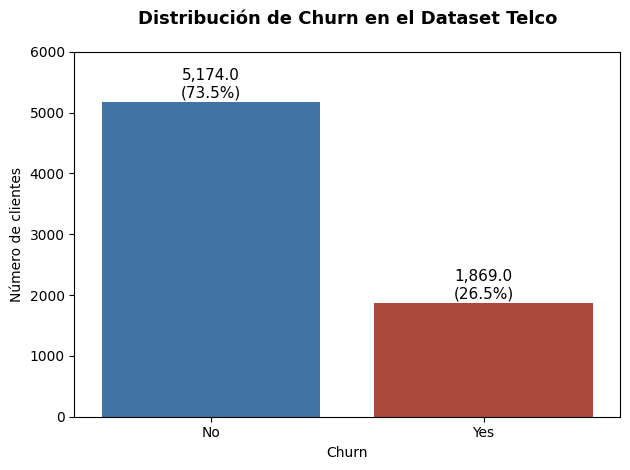

In [37]:
ax = sns.countplot(data=df, x='Churn', hue='Churn', legend=False,
                   palette={'No': '#2E75B6', 'Yes': '#C0392B'})

for p in ax.patches:
    ax.annotate(f'{p.get_height():,}\n({p.get_height()/len(df)*100:.1f}%)',
            (p.get_x() + p.get_width() / 2, p.get_height() + 30),
            ha='center', va='bottom', fontsize=11)
ax.set_ylim(0, 6000)
plt.title('Distribución de Churn en el Dataset Telco', fontsize=13, fontweight='bold', pad=20)
plt.xlabel('Churn')
plt.ylabel('Número de clientes')
plt.tight_layout()
plt.show()

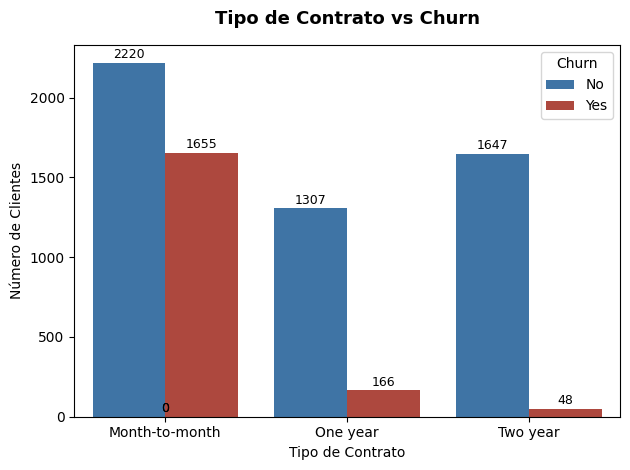

In [38]:
ax = sns.countplot(x='Contract', hue='Churn', data=df,
                   palette={'No': '#2E75B6', 'Yes': '#C0392B'})

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2, p.get_height() + 10),
                ha='center', va='bottom', fontsize=9)

plt.title('Tipo de Contrato vs Churn', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Tipo de Contrato')
plt.ylabel('Número de Clientes')
plt.legend(title='Churn', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

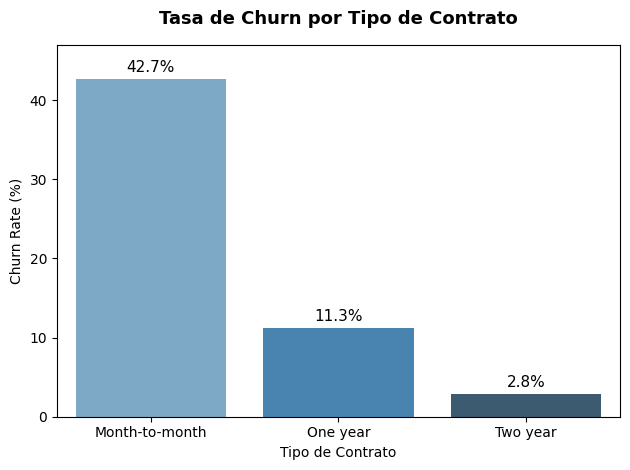

In [39]:
churn_rate = df.groupby('Contract')['Churn'].apply(lambda x: (x=='Yes').mean() * 100).reset_index()
churn_rate.columns = ['Contract', 'Churn Rate (%)']

ax = sns.barplot(data=churn_rate, x='Contract', y='Churn Rate (%)',
                 hue='Contract', legend=False,
                 palette='Blues_d')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2, p.get_height() + 0.5),
                ha='center', va='bottom', fontsize=11)
ax.set_ylim(0, 47)
plt.title('Tasa de Churn por Tipo de Contrato', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Tipo de Contrato')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show()

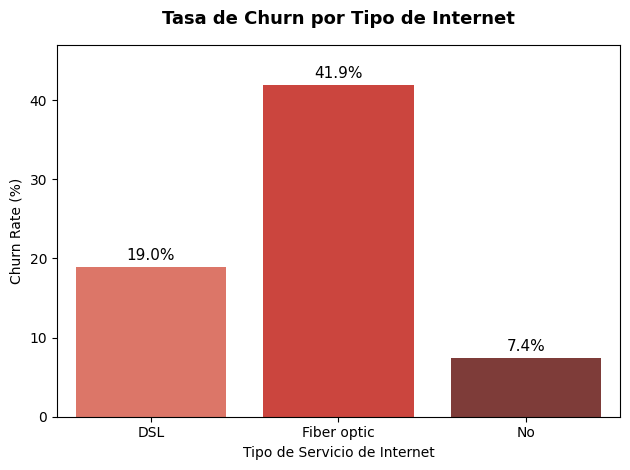

In [40]:
churn_rate2 = df.groupby('InternetService')['Churn'].apply(lambda x: (x=='Yes').mean() * 100).reset_index()
churn_rate2.columns = ['InternetService', 'Churn Rate (%)']

ax = sns.barplot(data=churn_rate2, x='InternetService', y='Churn Rate (%)',
                 hue='InternetService', legend=False,
                 palette='Reds_d')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2, p.get_height() + 0.5),
                ha='center', va='bottom', fontsize=11)
ax.set_ylim(0, 47)
plt.title('Tasa de Churn por Tipo de Internet', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Tipo de Servicio de Internet')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show()

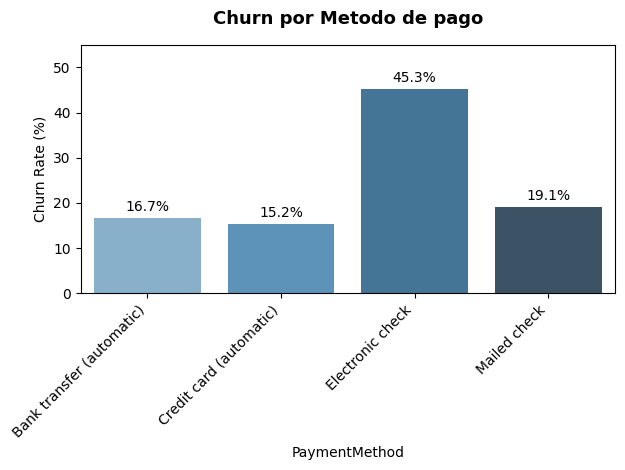

In [41]:
churn_payment_method = df.groupby('PaymentMethod')['Churn'].apply(lambda x: (x=='Yes').mean()*100).reset_index()
churn_payment_method.columns = ['PaymentMethod', 'Churn Rate (%)']
ax = sns.barplot(data=churn_payment_method, x='PaymentMethod', y='Churn Rate (%)',
            hue='PaymentMethod', legend=False, 
            palette='Blues_d')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)
    
ax.set_ylim(0, 55)
plt.title('Churn por Metodo de pago', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('PaymentMethod')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

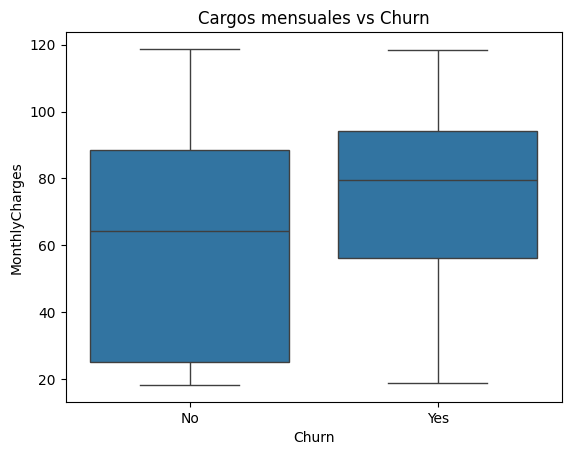

In [42]:
sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    data=df
)

plt.title("Cargos mensuales vs Churn")
plt.show()

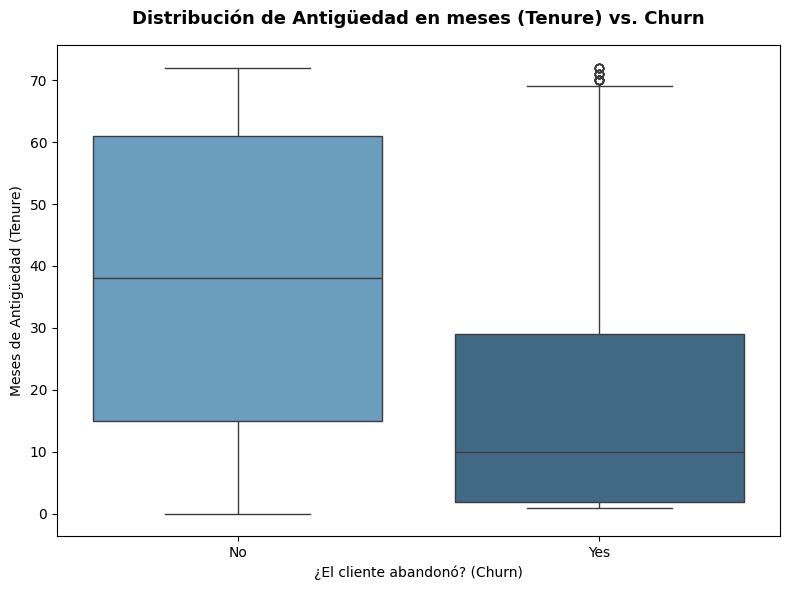

In [43]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Churn', y='tenure', hue='Churn', palette='Blues_d', legend=False)
plt.title('Distribución de Antigüedad en meses (Tenure) vs. Churn', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('¿El cliente abandonó? (Churn)')
plt.ylabel('Meses de Antigüedad (Tenure)')

plt.tight_layout()
plt.show()

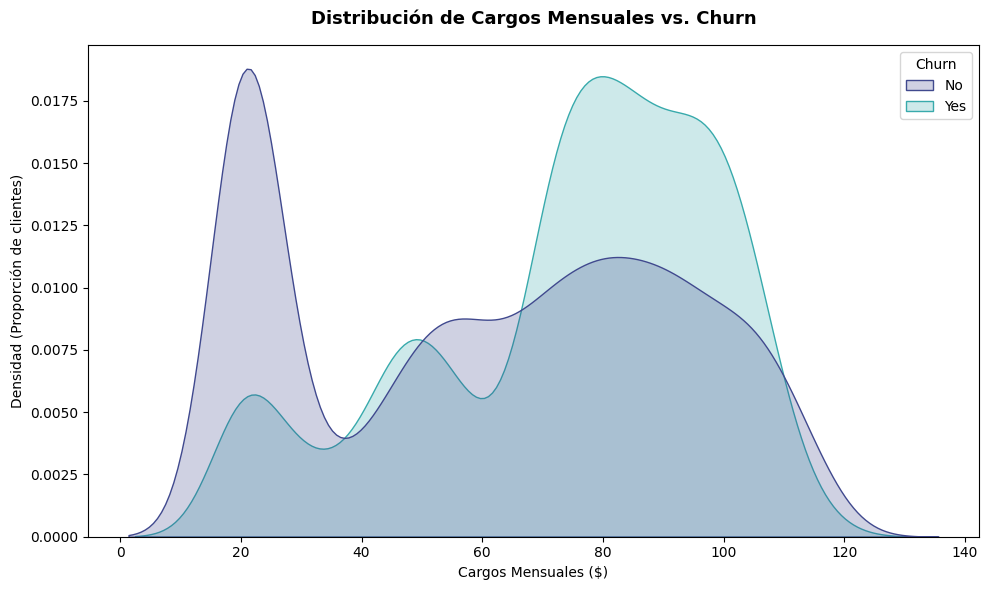

In [44]:
plt.figure(figsize=(10, 6))

sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True, common_norm=False, palette='mako')

plt.title('Distribución de Cargos Mensuales vs. Churn', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Cargos Mensuales ($)')
plt.ylabel('Densidad (Proporción de clientes)')

plt.tight_layout()
plt.show()

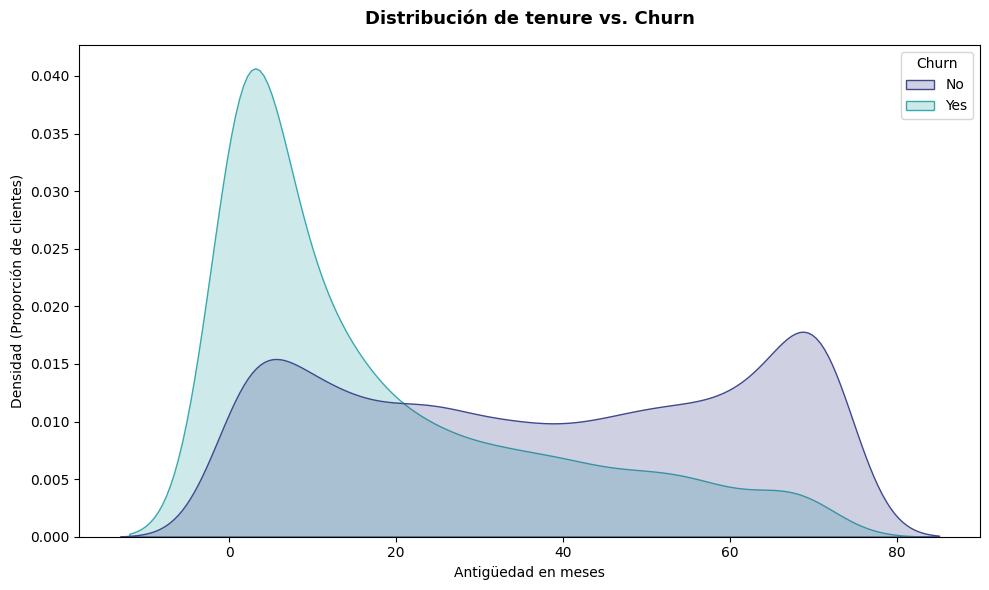

In [45]:
plt.figure(figsize=(10, 6))

sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True, common_norm=False, palette='mako')

plt.title('Distribución de tenure vs. Churn', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Antigüedad en meses')
plt.ylabel('Densidad (Proporción de clientes)')

plt.tight_layout()
plt.show()

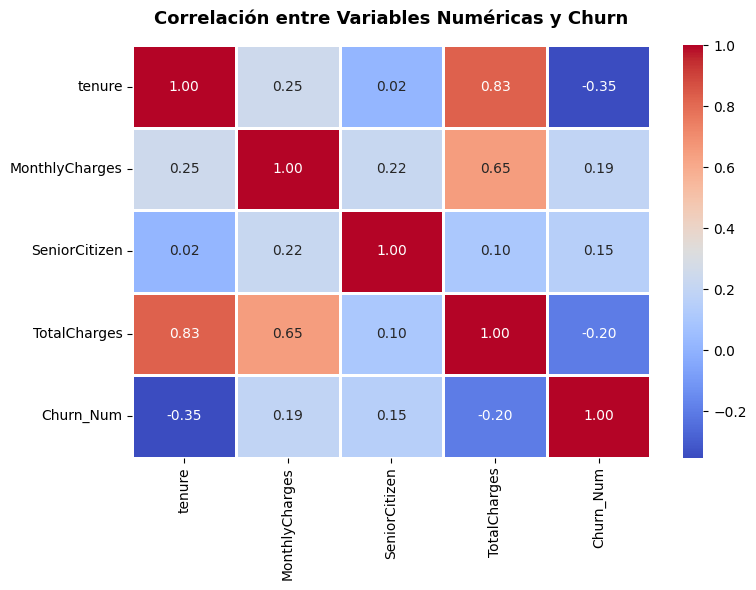

In [46]:
plt.figure(figsize=(8, 6))

df_corr = df[['tenure', 'MonthlyCharges', 'SeniorCitizen']].copy()
df_corr['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df_corr['Churn_Num'] = df['Churn'].map({'Yes': 1, 'No': 0})

sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=1)

plt.title('Correlación entre Variables Numéricas y Churn', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

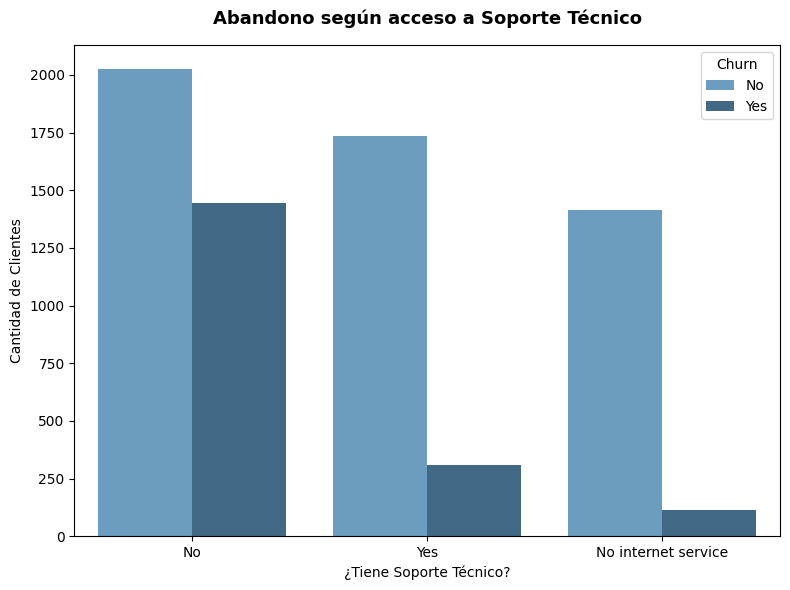

In [47]:
plt.figure(figsize=(8, 6))

sns.countplot(data=df, x='TechSupport', hue='Churn', palette='Blues_d')

plt.title('Abandono según acceso a Soporte Técnico', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('¿Tiene Soporte Técnico?')
plt.ylabel('Cantidad de Clientes')
plt.tight_layout()
plt.show()

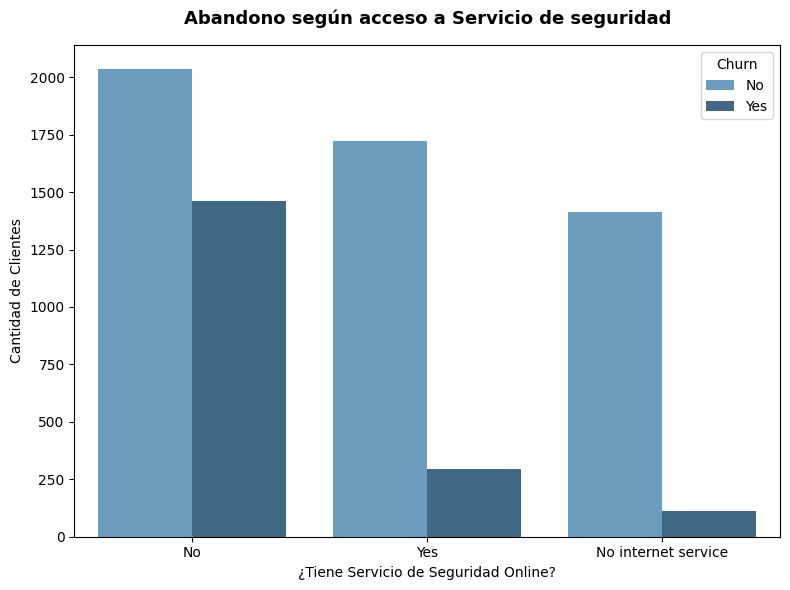

In [48]:
plt.figure(figsize=(8, 6))

sns.countplot(data=df, x='OnlineSecurity', hue='Churn', palette='Blues_d')

plt.title('Abandono según acceso a Servicio de seguridad', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('¿Tiene Servicio de Seguridad Online?')
plt.ylabel('Cantidad de Clientes')
plt.tight_layout()
plt.show()

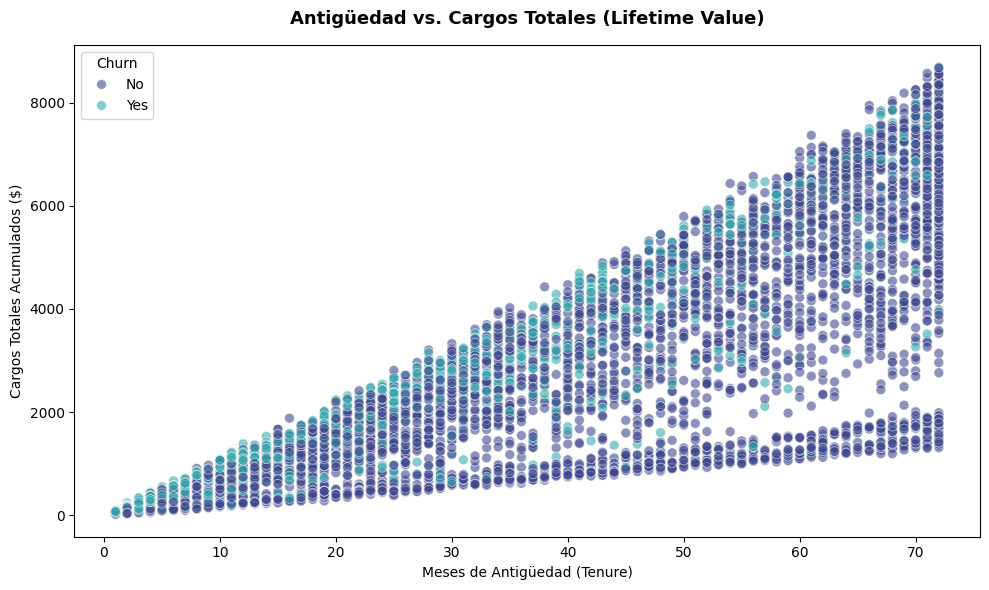

In [49]:
plt.figure(figsize=(10, 6))

df['TotalCharges_Num'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

sns.scatterplot(data=df, x='tenure', y='TotalCharges_Num', hue='Churn', 
                palette='mako', alpha=0.6, s=50)

plt.title('Antigüedad vs. Cargos Totales (Lifetime Value)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Meses de Antigüedad (Tenure)')
plt.ylabel('Cargos Totales Acumulados ($)')
plt.tight_layout()
plt.show()